# Chapter 10: Machine Learning Intro 2

In [23]:
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
import seaborn as sns; sns.set()
from sklearn import metrics
from sklearn import preprocessing

## 10.1 Introduction & Problem Setting

Congratulations on making it this far! You have come a long way and are now ready to tackle a real-world problem. 🎯

Today you will apply what you have learned to a new and specific case: **fraud detection**. Imagine you work at a bank processing important documents. Each document must contain a signature, and your job is to identify which signatures are forged and which are genuine. Your boss has provided you with a collection of real signatures from previous documents as well as forged ones to help train your detection system.

## 10.2 Data loading

Load in the images from the training set. You cannot store all individual pixels in a dataframe efficiently. Instead, think creatively about what information might distinguish a real signature from a forged one. Extract features that capture the essence of each signature.

*Hint: Load a single signature first and display it. Look for distinguishing features: How spread out are the lines? How much of the image is filled versus empty? What is the overall darkness or lightness?*

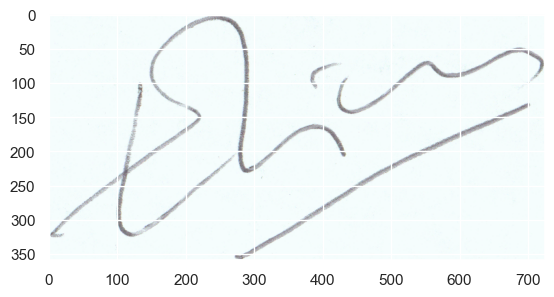

In [24]:
signature = img.imread("signatures_data/signatures train/001_01.png")
plt.imshow(signature)

Our signature images are black on a white background, so color information is not useful. Converting to grayscale reduces the data and makes sense for signatures.

Once we flatten the image into a single array, we can extract meaningful statistics: the mean tells us the average darkness, the standard deviation tells us how varied the darkness is, and the non-white pixel count tells us how much of the image contains ink.

We also calculate a histogram, which divides the pixel values into 10 bins. This shows us the distribution of light and dark areas. For example, a signature with very dark lines might have many pixels in the darker bins, while a signature with lighter strokes might be more spread across bins.

In [25]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [26]:
import cv2

In [27]:
training_files = listdir("signatures_data/signatures train")

signatures_train = pd.DataFrame(columns=["image", "mean", "std", "min", "max", "nonwhite_count", "hist_bin_1", "hist_bin_2", "hist_bin_3", "hist_bin_4", "hist_bin_5", "hist_bin_6", "hist_bin_7", "hist_bin_8", "hist_bin_9", "hist_bin_10"])

for file in training_files:
    signature_filepath = "signatures_data/signatures train/" + file
    signature = img.imread(signature_filepath)

    if len(signature.shape) == 3:
        gray = cv2.cvtColor(signature, cv2.COLOR_BGR2GRAY).flatten()
    else:
        gray = signature.flatten()
    
    mean_val = np.mean(gray)
    std_val = np.std(gray)
    min_val = np.min(gray)
    max_val = np.max(gray)
    nonwhite_count = np.count_nonzero(gray)
    hist = np.histogram(gray, bins=10, range=(0, 1))

    signatures_train.loc[len(signatures_train)] = {
                "image": file,
                "mean": mean_val,
                "std": std_val,
                "min": min_val,
                "max": max_val,
                "nonwhite_count": nonwhite_count,
                "hist_bin_1": hist[0][0],
                "hist_bin_2": hist[0][1],
                "hist_bin_3": hist[0][2],
                "hist_bin_4": hist[0][3],
                "hist_bin_5": hist[0][4],
                "hist_bin_6": hist[0][5],
                "hist_bin_7": hist[0][6],
                "hist_bin_8": hist[0][7],
                "hist_bin_9": hist[0][8],
                "hist_bin_10": hist[0][9]
            }

signatures_train.head(10)

,image,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10
0,001_01.PNG,0.970181,0.074476,0.358859,0.998212,260275,0,0,0,7,584,2813,4541,4221,2822,245287
1,001_04.PNG,0.972556,0.070922,0.333839,0.998212,295789,0,0,0,29,836,2937,4003,4021,2799,281164
2,001_05.PNG,0.971084,0.076140,0.377337,0.998212,252967,0,0,0,20,980,3076,3902,3001,2245,239743
3,001_06.PNG,0.971972,0.073021,0.287761,0.998212,262912,0,0,1,100,1025,2221,3757,4072,2479,249257
4,001_07.PNG,0.973504,0.068466,0.325576,0.998212,372957,0,0,0,65,1166,3021,5020,4446,2996,356243
5,001_08.PNG,0.972219,0.072467,0.304643,0.998212,276454,0,0,0,32,1117,2657,3738,3580,2404,262926
6,001_09.PNG,0.971715,0.076161,0.277773,0.998212,283113,0,0,1,20,1011,4305,3716,2162,1928,269970
7,001_10.PNG,0.970436,0.078610,0.348459,0.998212,338766,0,0,0,23,1521,5363,4570,2575,2493,322221
8,001_11.PNG,0.973340,0.068951,0.367533,0.998212,391348,0,0,0,26,1305,4109,4533,3418,2816,375141
9,001_12.PNG,0.966673,0.085033,0.326169,0.997765,258984,0,0,0,40,1196,5236,4065,2116,1859,244472


Next, build your outcome vector using the provided CSV file. Make sure to merge it correctly with the image data by matching on the image filenames. We will predict the 'forged' column, which tells us whether each signature is genuine (False) or forged (True).

In [28]:
outcome = pd.read_csv("signatures_data/signatures.csv", header = 0, sep = "%")
outcome.head()

,image,signature id,forged
0,001_01.PNG,1,False
1,001_02.PNG,1,False
2,001_03.PNG,1,False
3,001_04.PNG,1,False
4,001_05.PNG,1,False


In [29]:
outcome["signature id"].unique()

array([ 1,  2,  3,  4,  6,  9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56,
       57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69])

In [30]:
final_train = pd.merge(signatures_train, outcome, left_on = 'image', right_on = 'image')
final_train.head()

,image,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10,signature id,forged
0,001_01.PNG,0.970181,0.074476,0.358859,0.998212,260275,0,0,0,7,584,2813,4541,4221,2822,245287,1,False
1,001_04.PNG,0.972556,0.070922,0.333839,0.998212,295789,0,0,0,29,836,2937,4003,4021,2799,281164,1,False
2,001_05.PNG,0.971084,0.076140,0.377337,0.998212,252967,0,0,0,20,980,3076,3902,3001,2245,239743,1,False
3,001_06.PNG,0.971972,0.073021,0.287761,0.998212,262912,0,0,1,100,1025,2221,3757,4072,2479,249257,1,False
4,001_07.PNG,0.973504,0.068466,0.325576,0.998212,372957,0,0,0,65,1166,3021,5020,4446,2996,356243,1,False


In [31]:
X_train = final_train.drop(["signature id"], axis=1).drop(["forged"], axis=1).drop(["image"], axis=1)
Y_train = final_train["forged"]

## 10.3 Model Creation & Evaluation

Now train a Random Forest classifier just as we did in the main notebook. Then load the test set using the same feature extraction process and evaluate how well your model can detect forged signatures.

In [32]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train, Y_train)

RandomForestClassifier()

In [33]:
testing_files = listdir("signatures_data/signatures test")

signatures_test = pd.DataFrame(columns=["image", "mean", "std", "min", "max", "nonwhite_count", "hist_bin_1", "hist_bin_2", "hist_bin_3", "hist_bin_4", "hist_bin_5", "hist_bin_6", "hist_bin_7", "hist_bin_8", "hist_bin_9", "hist_bin_10"])

for file in testing_files:
    signature_filepath = "signatures_data/signatures test/" + file
    signature = img.imread(signature_filepath)

    if len(signature.shape) == 3:
        gray = cv2.cvtColor(signature, cv2.COLOR_BGR2GRAY).flatten()
    else:
        gray = signature.flatten()
    
    mean_val = np.mean(gray)
    std_val = np.std(gray)
    min_val = np.min(gray)
    max_val = np.max(gray)
    nonwhite_count = np.count_nonzero(gray)
    hist = np.histogram(gray, bins=10, range=(0, 1))

    signatures_test.loc[len(signatures_test)] = {
                "image": file,
                "mean": mean_val,
                "std": std_val,
                "min": min_val,
                "max": max_val,
                "nonwhite_count": nonwhite_count,
                "hist_bin_1": hist[0][0],
                "hist_bin_2": hist[0][1],
                "hist_bin_3": hist[0][2],
                "hist_bin_4": hist[0][3],
                "hist_bin_5": hist[0][4],
                "hist_bin_6": hist[0][5],
                "hist_bin_7": hist[0][6],
                "hist_bin_8": hist[0][7],
                "hist_bin_9": hist[0][8],
                "hist_bin_10": hist[0][9]
            }

final_test = pd.merge(signatures_test, outcome, left_on = 'image', right_on = 'image')
final_test.head(10)

,image,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10,signature id,forged
0,001_02.PNG,0.971921,0.071397,0.343863,0.997765,288782,0,0,0,43,787,2518,4385,4653,2793,273603,1,False
1,001_03.PNG,0.971958,0.069721,0.323682,0.998212,292719,0,0,0,35,650,2346,4264,5046,3680,276698,1,False
2,001_14.PNG,0.965429,0.098219,0.004471,0.989474,264420,52,75,322,1216,2881,3413,2511,1857,2009,250084,1,False
3,002_02.PNG,0.951848,0.116455,0.361169,0.998212,92075,0,0,0,49,1544,3332,1551,1125,1168,83306,2,False
4,002_03.PNG,0.951716,0.115883,0.338039,0.998212,91506,0,0,0,45,1549,3095,1748,1209,1307,82553,2,False
5,002_07.PNG,0.950025,0.117165,0.324973,0.998212,92400,0,0,0,59,1617,3217,1707,1283,1379,83138,2,False
6,002_18.PNG,0.941259,0.141816,0.004471,0.989474,87709,30,59,363,1302,1918,1885,1319,1178,1381,78274,2,False
7,002_22.PNG,0.934443,0.148804,0.023290,0.989474,83214,26,85,422,1536,2016,1673,1238,1188,1527,73503,2,False
8,002_23.PNG,0.932114,0.148991,0.026867,0.989474,81529,30,71,448,1402,2023,1729,1338,1214,1577,71697,2,False
9,003_03.PNG,0.866211,0.185409,0.262718,0.998212,40375,0,0,2,212,2175,4254,2899,1644,1443,27746,3,False


In [34]:
X_test = final_test.drop(["signature id"], axis=1).drop(["forged"], axis=1).drop(["image"], axis=1)
Y_test = final_test["forged"]

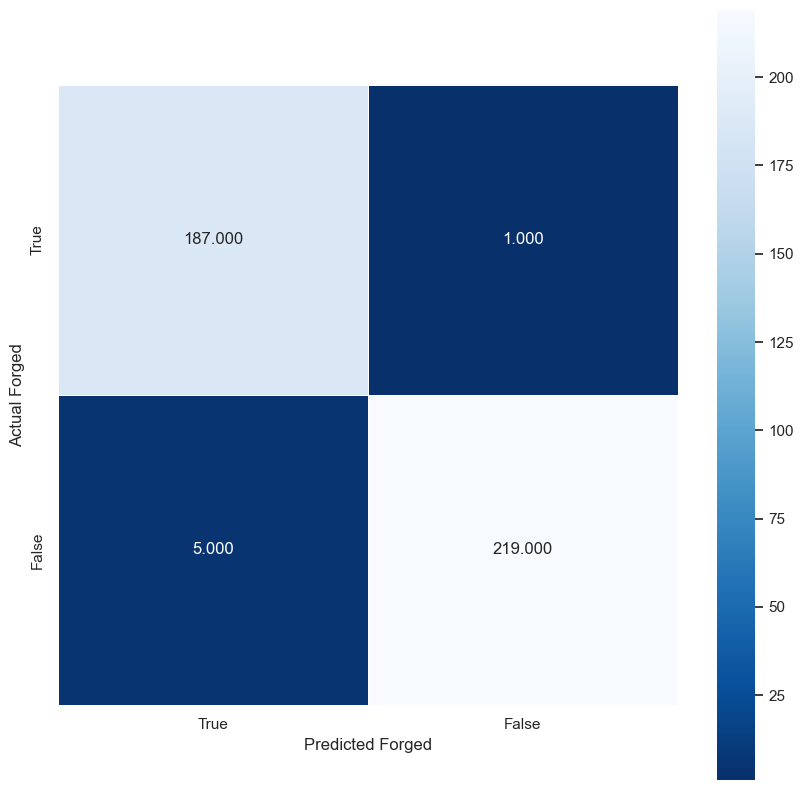

In [35]:
Y_pred = ML_model.predict(X_test)

labels = [True, False]
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(Y_test, Y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual Forged');
plt.xlabel('Predicted Forged');

## 10.4 Putting Your Model in Action

A new document arrives: "bank_statement.pdf". Let's use your trained model to determine if the signature is genuine or forged. 🔍

First, let's display the signature image from the document.

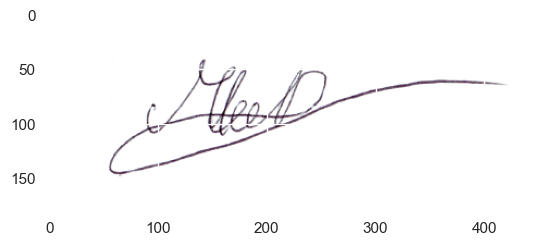

In [36]:
signature = img.imread("signatures_data/screenshot_signature_bank_statement.png")
plt.imshow(signature)

In [37]:
X_signature = pd.DataFrame(columns=["mean", "std", "min", "max", "nonwhite_count", "hist_bin_1", "hist_bin_2", "hist_bin_3", "hist_bin_4", "hist_bin_5", "hist_bin_6", "hist_bin_7", "hist_bin_8", "hist_bin_9", "hist_bin_10"])

signature_filepath = "signatures_data/signatures test/" + file
signature = img.imread(signature_filepath)

if len(signature.shape) == 3:
    gray = cv2.cvtColor(signature, cv2.COLOR_BGR2GRAY).flatten()
else:
    gray = signature.flatten()

mean_val = np.mean(gray)
std_val = np.std(gray)
min_val = np.min(gray)
max_val = np.max(gray)
nonwhite_count = np.count_nonzero(gray)
hist = np.histogram(gray, bins=10, range=(0, 1))

X_signature.loc[0] = {
            "mean": mean_val,
            "std": std_val,
            "min": min_val,
            "max": max_val,
            "nonwhite_count": nonwhite_count,
            "hist_bin_1": hist[0][0],
            "hist_bin_2": hist[0][1],
            "hist_bin_3": hist[0][2],
            "hist_bin_4": hist[0][3],
            "hist_bin_5": hist[0][4],
            "hist_bin_6": hist[0][5],
            "hist_bin_7": hist[0][6],
            "hist_bin_8": hist[0][7],
            "hist_bin_9": hist[0][8],
            "hist_bin_10": hist[0][9]
        }

X_signature.head()

,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10
0,0.905339,0.162073,0.277529,0.997765,66516,0,0,1,243,2630,4356,3105,1943,1998,52240


In [38]:
ML_model.predict(X_signature)

array([False])

Based on the statistical features of this signature, our model predicts whether it is genuine or forged.

## 10.5 Bonus Challenge (Not Required)

**Can you build a model that identifies WHO signed the document?** Instead of detecting fraud, predict which person (by ID) created each signature. This is called signature verification and uses the same features. How well can your model identify individual signers? 🎯

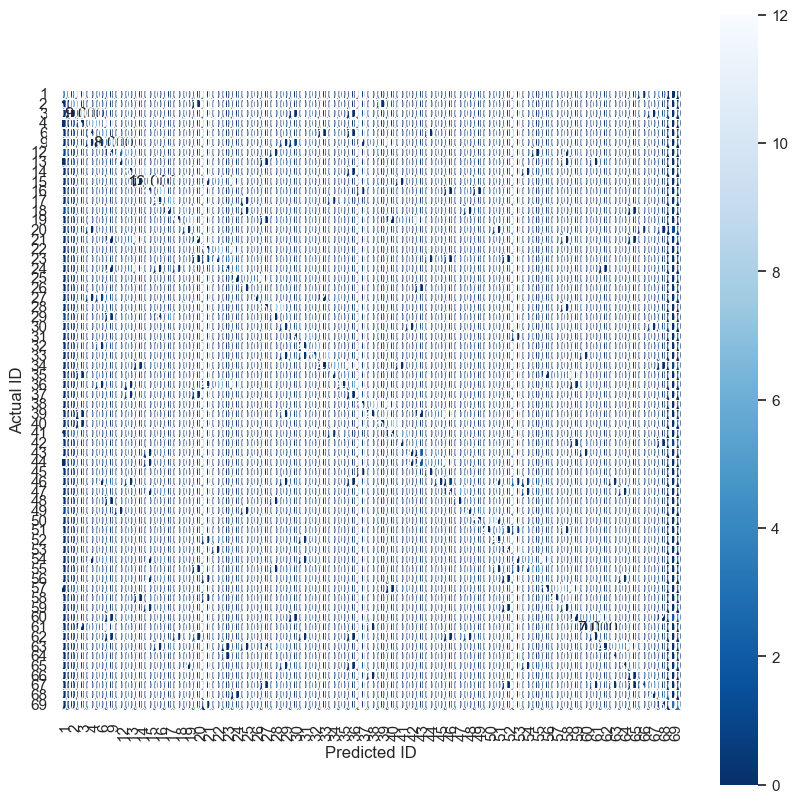

In [39]:
X_train = final_train.drop(["signature id"], axis=1).drop(["forged"], axis=1).drop(["image"], axis=1)
Y_train = final_train["signature id"]

X_test = final_test.drop(["signature id"], axis=1).drop(["forged"], axis=1).drop(["image"], axis=1)
Y_test = final_test["signature id"]

ID_model = RandomForestClassifier()
ID_model.fit(X_train, Y_train)

Y_pred = ID_model.predict(X_test)

labels = [ 1,  2,  3,  4,  6,  9, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
       40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56,
       57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(Y_test, Y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual ID');
plt.xlabel('Predicted ID');

In [40]:
ID_model.score(X_test, Y_test)

0.5242718446601942

## 10.6 Exercise Summary

### What You Built

You created a **fraud detection system** for signatures using Machine Learning. Instead of manually inspecting each document, your model can now automatically classify signatures as genuine or forged.

### The Feature Engineering Strategy

The key to your success was extracting the right features from images. You chose:
- **Mean pixel value**: Captures overall darkness
- **Standard deviation**: Shows variation in darkness (pen pressure varies)
- **Minimum and maximum values**: Indicate the darkest and lightest parts
- **Non-white pixel count**: Measures how much of the document contains ink
- **Histogram bins**: Show the distribution across different darkness levels

These 15 features transformed each image from 65,536 pixel values into a manageable representation that preserves the signature's essential characteristics.

### Why This Approach Works

Forged signatures often have telltale differences from genuine ones: different pressure patterns, different spacing, different overall darkness. Your model learned to recognize these patterns from the training data and apply that knowledge to new, unseen signatures.

### The Bonus Challenge

The bonus section explored an even more advanced task: **identifying which person signed the document**. Each person has a unique signature style, and your model can learn to recognize these individual patterns. This is the foundation of modern biometric security systems! 🔐

### Key Takeaway

This exercise shows how **domain knowledge + data engineering = powerful ML systems**. You didn't need fancy deep learning models; you just needed to think carefully about what features matter and extract them intelligently.